In [2]:
#importamos pandas y identificamos nuestro dataframe

import pandas as pd
import matplotlib.pyplot as plt
import random
df=pd.read_csv('ventas_proyecto.csv')   
# Lista de nombres de vendedores (puedes agregar más si lo prefieres)
vendedores = ['Vendedor 1', 'Vendedor 2', 'Vendedor 3', 'Vendedor 4', 'Vendedor 5']

# Asignamos aleatoriamente un vendedor a cada fila del DataFrame
df['Vendedor'] = [random.choice(vendedores) for _ in range(len(df))]

# Verificamos que la columna Vendedor fue añadida
print(df.head())     


  ID_Factura       Fecha Producto        Ciudad    Sucursal  Cantidad  \
0      F1000  2025-02-21   Laptop       Mendoza  Sucursal A         7   
1      F1001  2025-01-15   Laptop         Salta  Sucursal A         8   
2      F1002  2025-03-13   Laptop  Buenos Aires  Sucursal C         4   
3      F1003  2025-03-02  Monitor  Buenos Aires  Sucursal C         2   
4      F1004  2025-01-21  Teclado       Rosario  Sucursal A         3   

   Precio_Unitario    Categoría  Total    Vendedor  
0              287  Electrónica   2009  Vendedor 5  
1              388  Electrónica   3104  Vendedor 3  
2              202  Electrónica    808  Vendedor 4  
3               32  Electrónica     64  Vendedor 1  
4              298  Electrónica    894  Vendedor 2  


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   ID_Factura       100 non-null    object
 1   Fecha            100 non-null    object
 2   Producto         100 non-null    object
 3   Ciudad           100 non-null    object
 4   Sucursal         100 non-null    object
 5   Cantidad         100 non-null    int64 
 6   Precio_Unitario  100 non-null    int64 
 7   Categoría        100 non-null    object
 8   Total            100 non-null    int64 
 9   Vendedor         100 non-null    object
dtypes: int64(3), object(7)
memory usage: 7.9+ KB


In [4]:
#ordenamos los productos de mas vendido a menos vendidos
producto_mas_vendido = df.groupby('Producto')['Cantidad'].sum().sort_values(ascending=False)
print(producto_mas_vendido)

Producto
Laptop         143
Monitor         92
Teclado         83
Auriculares     72
Mouse           72
Name: Cantidad, dtype: int64


In [ ]:
#creamos dataframe con una relacion cantidad de producto vendidos con la ganacia total
ventas_ciudad=df.groupby('Producto')[['Cantidad','Total']].sum().sort_values(by='Total', ascending=False)
print(ventas_ciudad)

             Cantidad  Total
Producto                    
Laptop            143  35634
Monitor            92  23402
Teclado            83  22646
Mouse              72  16985
Auriculares        72  16292


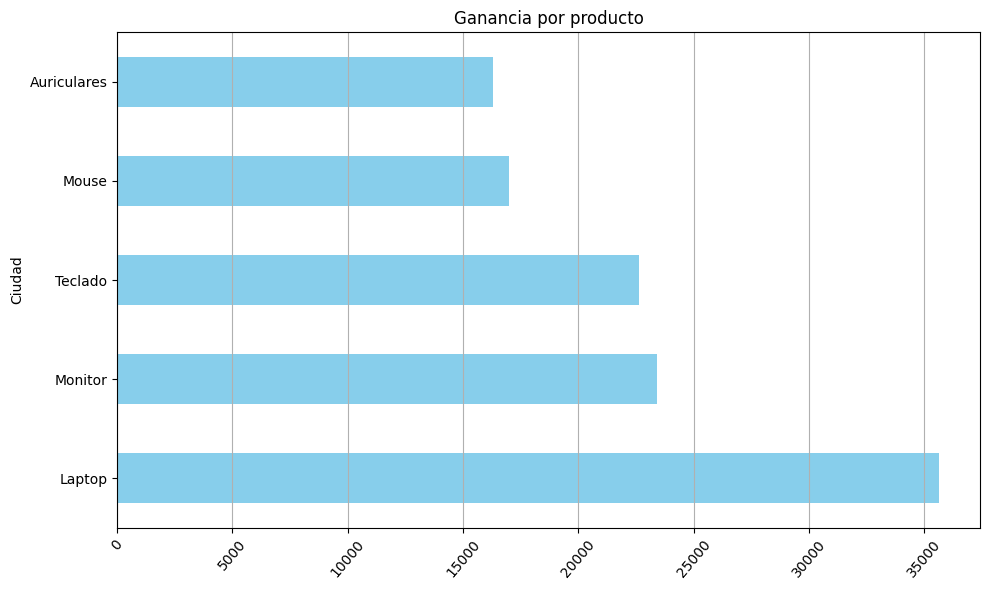

In [26]:
ventas_ciudad['Total'].plot(kind='barh', figsize=(10, 6), color='skyblue')
plt.title('Ganancia por producto')
plt.xlabel('')
plt.ylabel('Ciudad')
plt.xticks(rotation=50)
plt.grid(axis='x')
plt.tight_layout()
plt.show()

In [7]:
producto_df=df.groupby('Producto')[['Total','Cantidad']].sum().sort_values(by='Cantidad', ascending=False)
print(producto_df)


             Total  Cantidad
Producto                    
Laptop       35634       143
Monitor      23402        92
Teclado      22646        83
Auriculares  16292        72
Mouse        16985        72


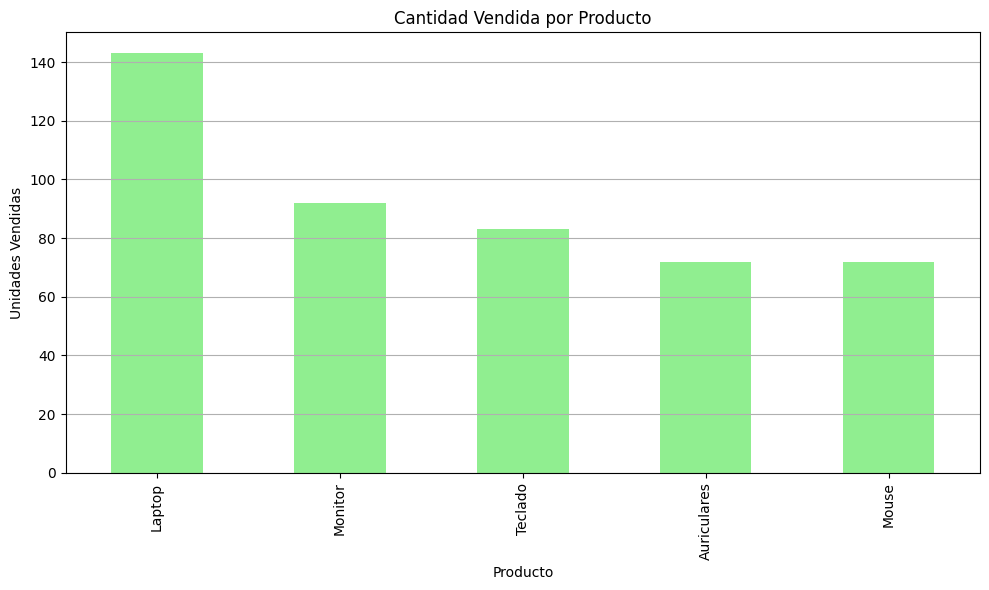

In [ ]:
#grafico de productos vendidos
producto_df['Cantidad'].plot(kind='bar', figsize=(10, 6), color='lightgreen')
plt.title('Cantidad Vendida por Producto')
plt.xlabel('Producto')
plt.ylabel('Unidades Vendidas')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [9]:
producto_df=df.groupby('Producto')[['Total','Cantidad']].sum().sort_values(by='Total', ascending=False)
print(producto_df.head(3))

          Total  Cantidad
Producto                 
Laptop    35634       143
Monitor   23402        92
Teclado   22646        83


In [ ]:
#dataframe ciudad,producto,total,cantidad organizado por total de ventas

ventas_ciudad_producto=df.groupby(['Ciudad','Producto'])[['Total','Cantidad']].sum().sort_values(by='Total', ascending=False)
ventas_ciudad_producto=ventas_ciudad_producto.reset_index()
ventas_ciudad_producto

,Ciudad,Producto,Total,Cantidad
0,Rosario,Laptop,13362,48
1,Buenos Aires,Laptop,8366,30
2,Rosario,Auriculares,8010,36
3,Mendoza,Teclado,7483,24
4,Rosario,Monitor,7246,21
5,Mendoza,Monitor,6918,26
6,Buenos Aires,Monitor,6887,39
7,Salta,Laptop,6528,25
8,Buenos Aires,Mouse,6426,35
9,Córdoba,Teclado,6247,26


In [ ]:
#dataframe del producto mas vendido por ciudad y ordenado en mayor cantidad de ganancia
top_producto_por_ciudad = ventas_ciudad_producto.sort_values(by='Cantidad', ascending=False).groupby('Ciudad').first().reset_index()
top_producto_por_ciudad = top_producto_por_ciudad.sort_values(by='Total', ascending=False)
print(top_producto_por_ciudad)

         Ciudad Producto  Total  Cantidad
3       Rosario   Laptop  13362        48
0  Buenos Aires  Monitor   6887        39
4         Salta   Laptop   6528        25
1       Córdoba  Teclado   6247        26
2       Mendoza   Laptop   5683        31


In [ ]:
#df de mayor cantidad de ventas por vendedor
ventas_vendedores=df.groupby('Vendedor')[['Total','Cantidad']].sum().sort_values(by='Total',ascending=False)
ventas_vendedores

,Total,Cantidad
Vendedor,,
Vendedor 5,34207,126
Vendedor 3,27798,101
Vendedor 2,27718,107
Vendedor 4,19163,84
Vendedor 1,6073,44


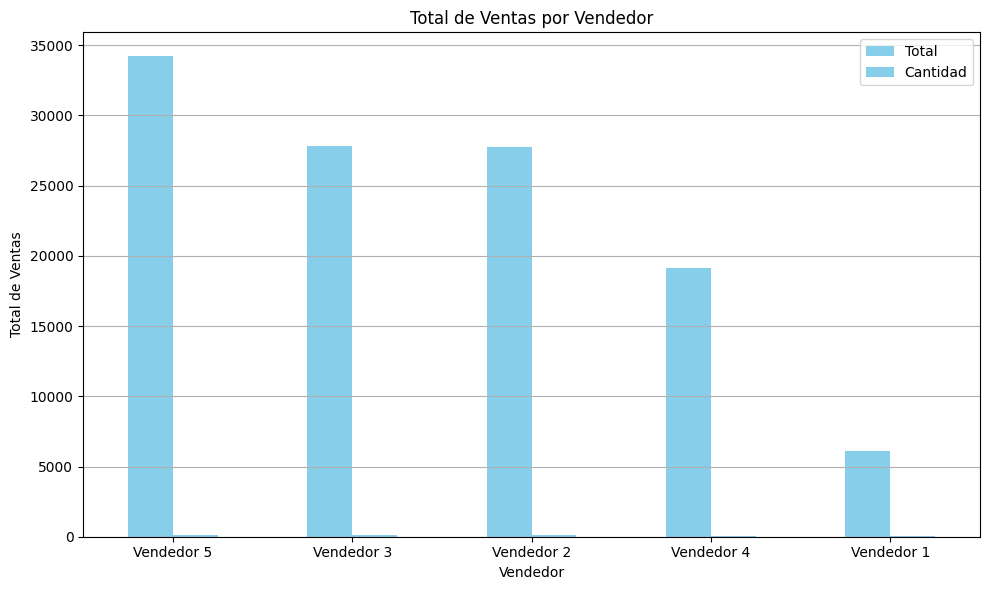

In [ ]:
#grafico de cantidad de ventas por vendedor
ventas_vendedores.plot(kind='bar',figsize=(10,6),color='skyblue')
plt.title('Total de Ventas por Vendedor')
plt.xlabel('Vendedor')
plt.ylabel('Total de Ventas')
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()

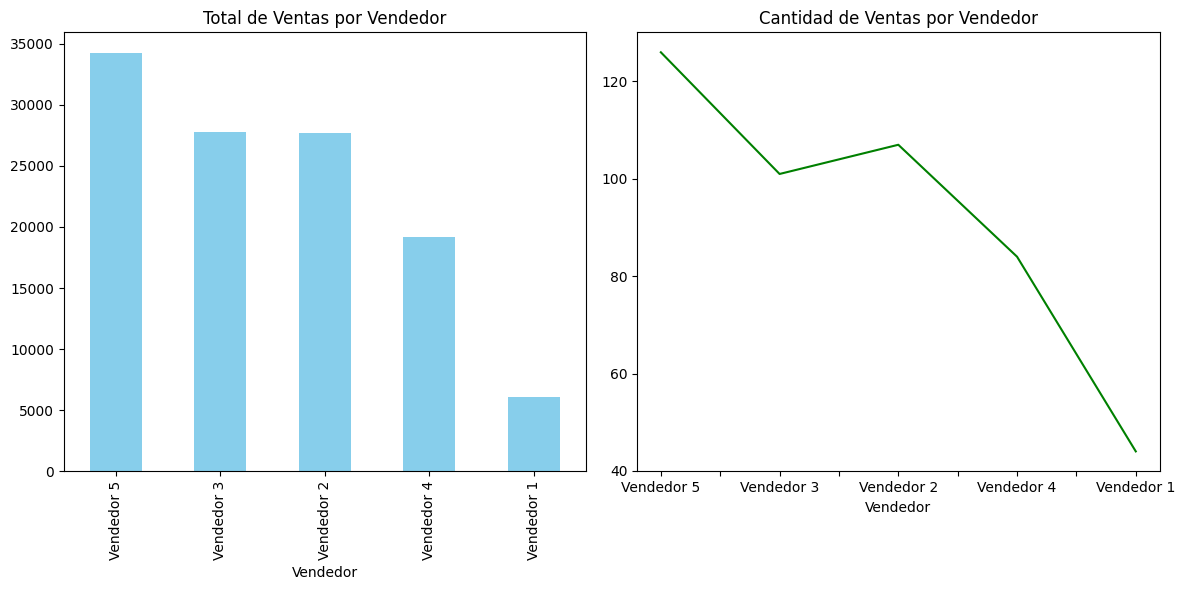

In [14]:
#Crear una figura con 2 subgráficos
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Primer gráfico de barras (en el primer subgráfico)
ventas_vendedores['Total'].plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Total de Ventas por Vendedor')

# Segundo gráfico de línea (en el segundo subgráfico)
ventas_vendedores['Cantidad'].plot(kind='line', ax=axes[1], color='green')
axes[1].set_title('Cantidad de Ventas por Vendedor')

plt.tight_layout()
plt.show()

In [ ]:
#df de total de ventas por vendedor
total_por_vendedor = df.groupby('Vendedor')['Total'].sum().reset_index()
total_por_vendedor = total_por_vendedor.rename(columns={'Total': 'Total Vendedor'})
total_por_vendedor.sort_values(by='Total Vendedor', ascending=False)

,Vendedor,Total Vendedor
4,Vendedor 5,34207
2,Vendedor 3,27798
1,Vendedor 2,27718
3,Vendedor 4,19163
0,Vendedor 1,6073


In [ ]:
#df de ganancia total por producto de cada vendedor
ventas_vendedor_producto = df.groupby(['Vendedor', 'Producto'])['Total'].sum()
ventas_vendedor_producto

Vendedor    Producto   
Vendedor 1  Auriculares     1031
            Laptop          1618
            Monitor          298
            Mouse           1702
            Teclado         1424
Vendedor 2  Auriculares     4532
            Laptop          5642
            Monitor         6920
            Mouse           2512
            Teclado         8112
Vendedor 3  Auriculares     3226
            Laptop          7876
            Monitor         9970
            Mouse           3897
            Teclado         2829
Vendedor 4  Auriculares     2896
            Laptop          9113
            Monitor         2051
            Mouse           2217
            Teclado         2886
Vendedor 5  Auriculares     4607
            Laptop         11385
            Monitor         4163
            Mouse           6657
            Teclado         7395
Name: Total, dtype: int64

In [ ]:
#union de 2 dateframe a traves de la columna vendedor
df_completo=total_por_vendedor.merge(ventas_vendedor_producto, on='Vendedor')
df_completo['Percentual'] = (df_completo['Total'] / df_completo['Total Vendedor']) * 100
df_completo.sort_values(by='Percentual').reset_index()

,index,Vendedor,Total Vendedor,Total,Percentual
0,2,Vendedor 1,6073,298,4.906965
1,8,Vendedor 2,27718,2512,9.062703
2,14,Vendedor 3,27798,2829,10.176991
3,17,Vendedor 4,19163,2051,10.702917
4,18,Vendedor 4,19163,2217,11.569170
5,10,Vendedor 3,27798,3226,11.605151
6,22,Vendedor 5,34207,4163,12.170024
7,20,Vendedor 5,34207,4607,13.468004
8,13,Vendedor 3,27798,3897,14.018994
9,19,Vendedor 4,19163,2886,15.060272


In [ ]:
#dataframe de cantidad de productos vendidos y ganancia generada por ciudad
ciudad_producto=df.sort_values(by='Total', ascending=False).groupby(['Ciudad','Producto'])['Total'].sum()
ciudad_producto

Ciudad        Producto   
Buenos Aires  Auriculares     1617
              Laptop          8366
              Monitor         6887
              Mouse           6426
              Teclado         3326
Córdoba       Auriculares     2730
              Laptop          1695
              Monitor         2351
              Mouse            815
              Teclado         6247
Mendoza       Auriculares      608
              Laptop          5683
              Monitor         6918
              Mouse           5842
              Teclado         7483
Rosario       Auriculares     8010
              Laptop         13362
              Monitor         7246
              Mouse           1083
              Teclado         2834
Salta         Auriculares     3327
              Laptop          6528
              Mouse           2819
              Teclado         2756
Name: Total, dtype: int64

In [ ]:
#mayor ganancia de producto por ciudad
max_ciudad=ciudad_producto.groupby('Ciudad').first()
max_ciudad.sort_values(by='Total',ascending=False)

,Producto,Total
Ciudad,,
Rosario,Auriculares,8010
Salta,Auriculares,3327
Córdoba,Auriculares,2730
Buenos Aires,Auriculares,1617
Mendoza,Auriculares,608


In [ ]:
#union de 2 data frame por la columna de ciudad mostrando ingreso total y el mayor producto vendido
total_ciudad=df.groupby('Ciudad')['Total'].sum().reset_index()
df_final=pd.merge(total_ciudad,max_ciudad, on='Ciudad',suffixes=(' Ciudad', ' Producto'))
df_final

,Ciudad,Total Ciudad,Producto,Total Producto
0,Buenos Aires,26622,Auriculares,1617
1,Córdoba,13838,Auriculares,2730
2,Mendoza,26534,Auriculares,608
3,Rosario,32535,Auriculares,8010
4,Salta,15430,Auriculares,3327


In [ ]:
#porcentaje de ganancia del producto con mas indice de ganancia por region
df_final['Porcentaje']=(df_final['Total Producto']/df_final['Total Ciudad'])*100
df_final

,Ciudad,Total Ciudad,Producto,Total Producto,Porcentaje
0,Buenos Aires,26622,Auriculares,1617,6.073924
1,Córdoba,13838,Auriculares,2730,19.728284
2,Mendoza,26534,Auriculares,608,2.291400
3,Rosario,32535,Auriculares,8010,24.619640
4,Salta,15430,Auriculares,3327,21.561892


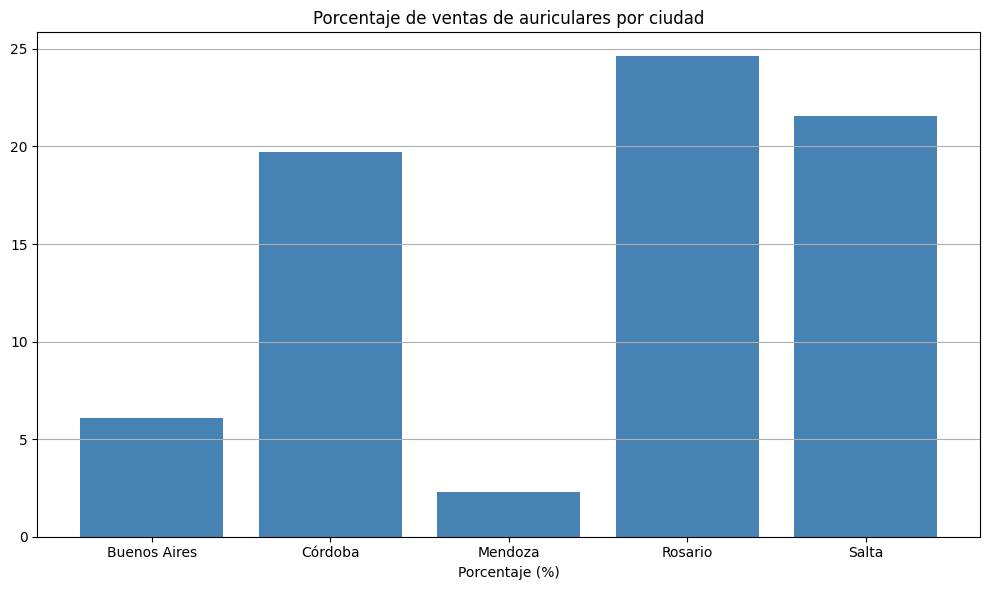

In [22]:
plt.figure(figsize=(10, 6))
plt.bar(df_final['Ciudad'], df_final['Porcentaje'], color='steelblue')
plt.xlabel('Porcentaje (%)')
plt.title('Porcentaje de ventas de auriculares por ciudad')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [23]:
plt.savefig('ventas_auriculares_por_ciudad.png', dpi=300)

<Figure size 640x480 with 0 Axes>